# Análise Diabetes - Regressão Linear


- Descobrir as 2 colunas mais impactantes na progressão da diabetes

- Propor um tamanho de treinamento e random state melhores para a precisão do treinamento


- MSE - Quanto menor, melhor
- R² - Quanto mais próximo de 1, melhor

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
dados = load_diabetes()

df = pd.DataFrame(dados.data, columns=dados.feature_names)
df["Alvo"] = dados.target

display(df)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Alvo
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [15]:
dados_preditivos = df[dados.feature_names]

alvos = df["Alvo"]

dados_preditivos_treino, dados_preditivos_teste, alvos_treino, alvos_teste = train_test_split(dados_preditivos, alvos, test_size=0.3, random_state=42)

linear = LinearRegression()
linear.fit(dados_preditivos_treino, alvos_treino)

alvos_previsao = linear.predict(dados_preditivos_teste)

df_previsao = dados_preditivos_teste
df_previsao["Alvo Previsto"] = alvos_previsao
df_previsao["Alvo Gabarito"] = alvos_teste

display(df_previsao.head())

mse = mean_squared_error(alvos_teste, alvos_previsao)
r2 = r2_score(alvos_teste, alvos_previsao)

display(f'MSE: {mse:4f}')
display(f"R2: {r2:4f}")


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Alvo Previsto,Alvo Gabarito
287,0.045341,-0.044642,-0.006206,-0.015999,0.125019,0.125198,0.019187,0.034309,0.032432,-0.005220,138.469700,219.0
211,0.092564,-0.044642,0.036907,0.021872,-0.024960,-0.016658,0.000779,-0.039493,-0.022517,-0.021788,181.100523,70.0
72,0.063504,0.050680,-0.004050,-0.012556,0.103003,0.048790,0.056003,-0.002592,0.084492,-0.017646,125.344009,202.0
321,0.096197,-0.044642,0.051996,0.079265,0.054845,0.036577,-0.076536,0.141322,0.098648,0.061054,292.759773,230.0
73,0.012648,0.050680,-0.020218,-0.002228,0.038334,0.053174,-0.006584,0.034309,-0.005142,-0.009362,123.883053,111.0


'MSE: 2821.750981'

'R2: 0.477290'

,Dado Preditivo,Coeficiente
0,age,29.254013
1,sex,-261.706469
2,bmi,546.299723
3,bp,388.398341
4,s1,-901.959668
5,s2,506.763241
6,s3,121.154351
7,s4,288.035267
8,s5,659.268951
9,s6,41.376701


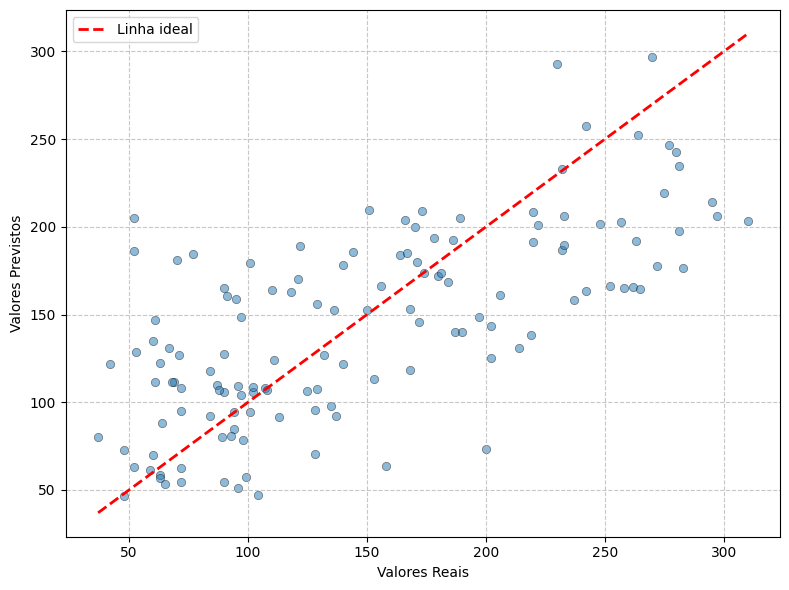

In [16]:
coeficientes = pd.DataFrame({
    "Dado Preditivo": dados.feature_names,
    "Coeficiente": linear.coef_
})

display(coeficientes)    

plt.figure(figsize=(8, 6))

plt.scatter(alvos_teste, alvos_previsao, alpha=0.5, edgecolors='k', linewidths=0.5)
plt.plot([alvos_teste.min(), alvos_teste.max()], [alvos_teste.min(), alvos_teste.max()], 'r--', lw=2, label="Linha ideal")

plt.xlabel("Valores Reais")
plt.ylabel("Valores Previstos")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()